# Dataset description
## Internal and external debt as percentage of Total

**Source**: Ministerio de Hacienda

**Download**: [link](https://www.irc.gov.co/deuda-publica/perfil-deuda-publica-gnc)

# Code
## imports

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
from highlight_text import fig_text
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from pathlib import Path
import matplotlib.dates as mdates

BASE_DIR = Path.cwd().parent.parent
pd.set_option("display.float_format", lambda x: "%.2f" % x)

## Load data

In [62]:
path = "data/saldos.csv"
logo_path = BASE_DIR / "logo/logo.png"

df = pd.read_csv(path, encoding="utf-8")
logo = plt.imread(logo_path)

## Clean data

In [63]:
df["Fecha"] = pd.to_datetime(df["Fecha"])
pctg_change = pd.DataFrame(
    {"Internal": (df["Deuda interna"] / df["Deuda total"]) * 100,
    "External": (df["Deuda externa"] / df["Deuda total"]) * 100},
).set_index(df["Fecha"])

## Plot

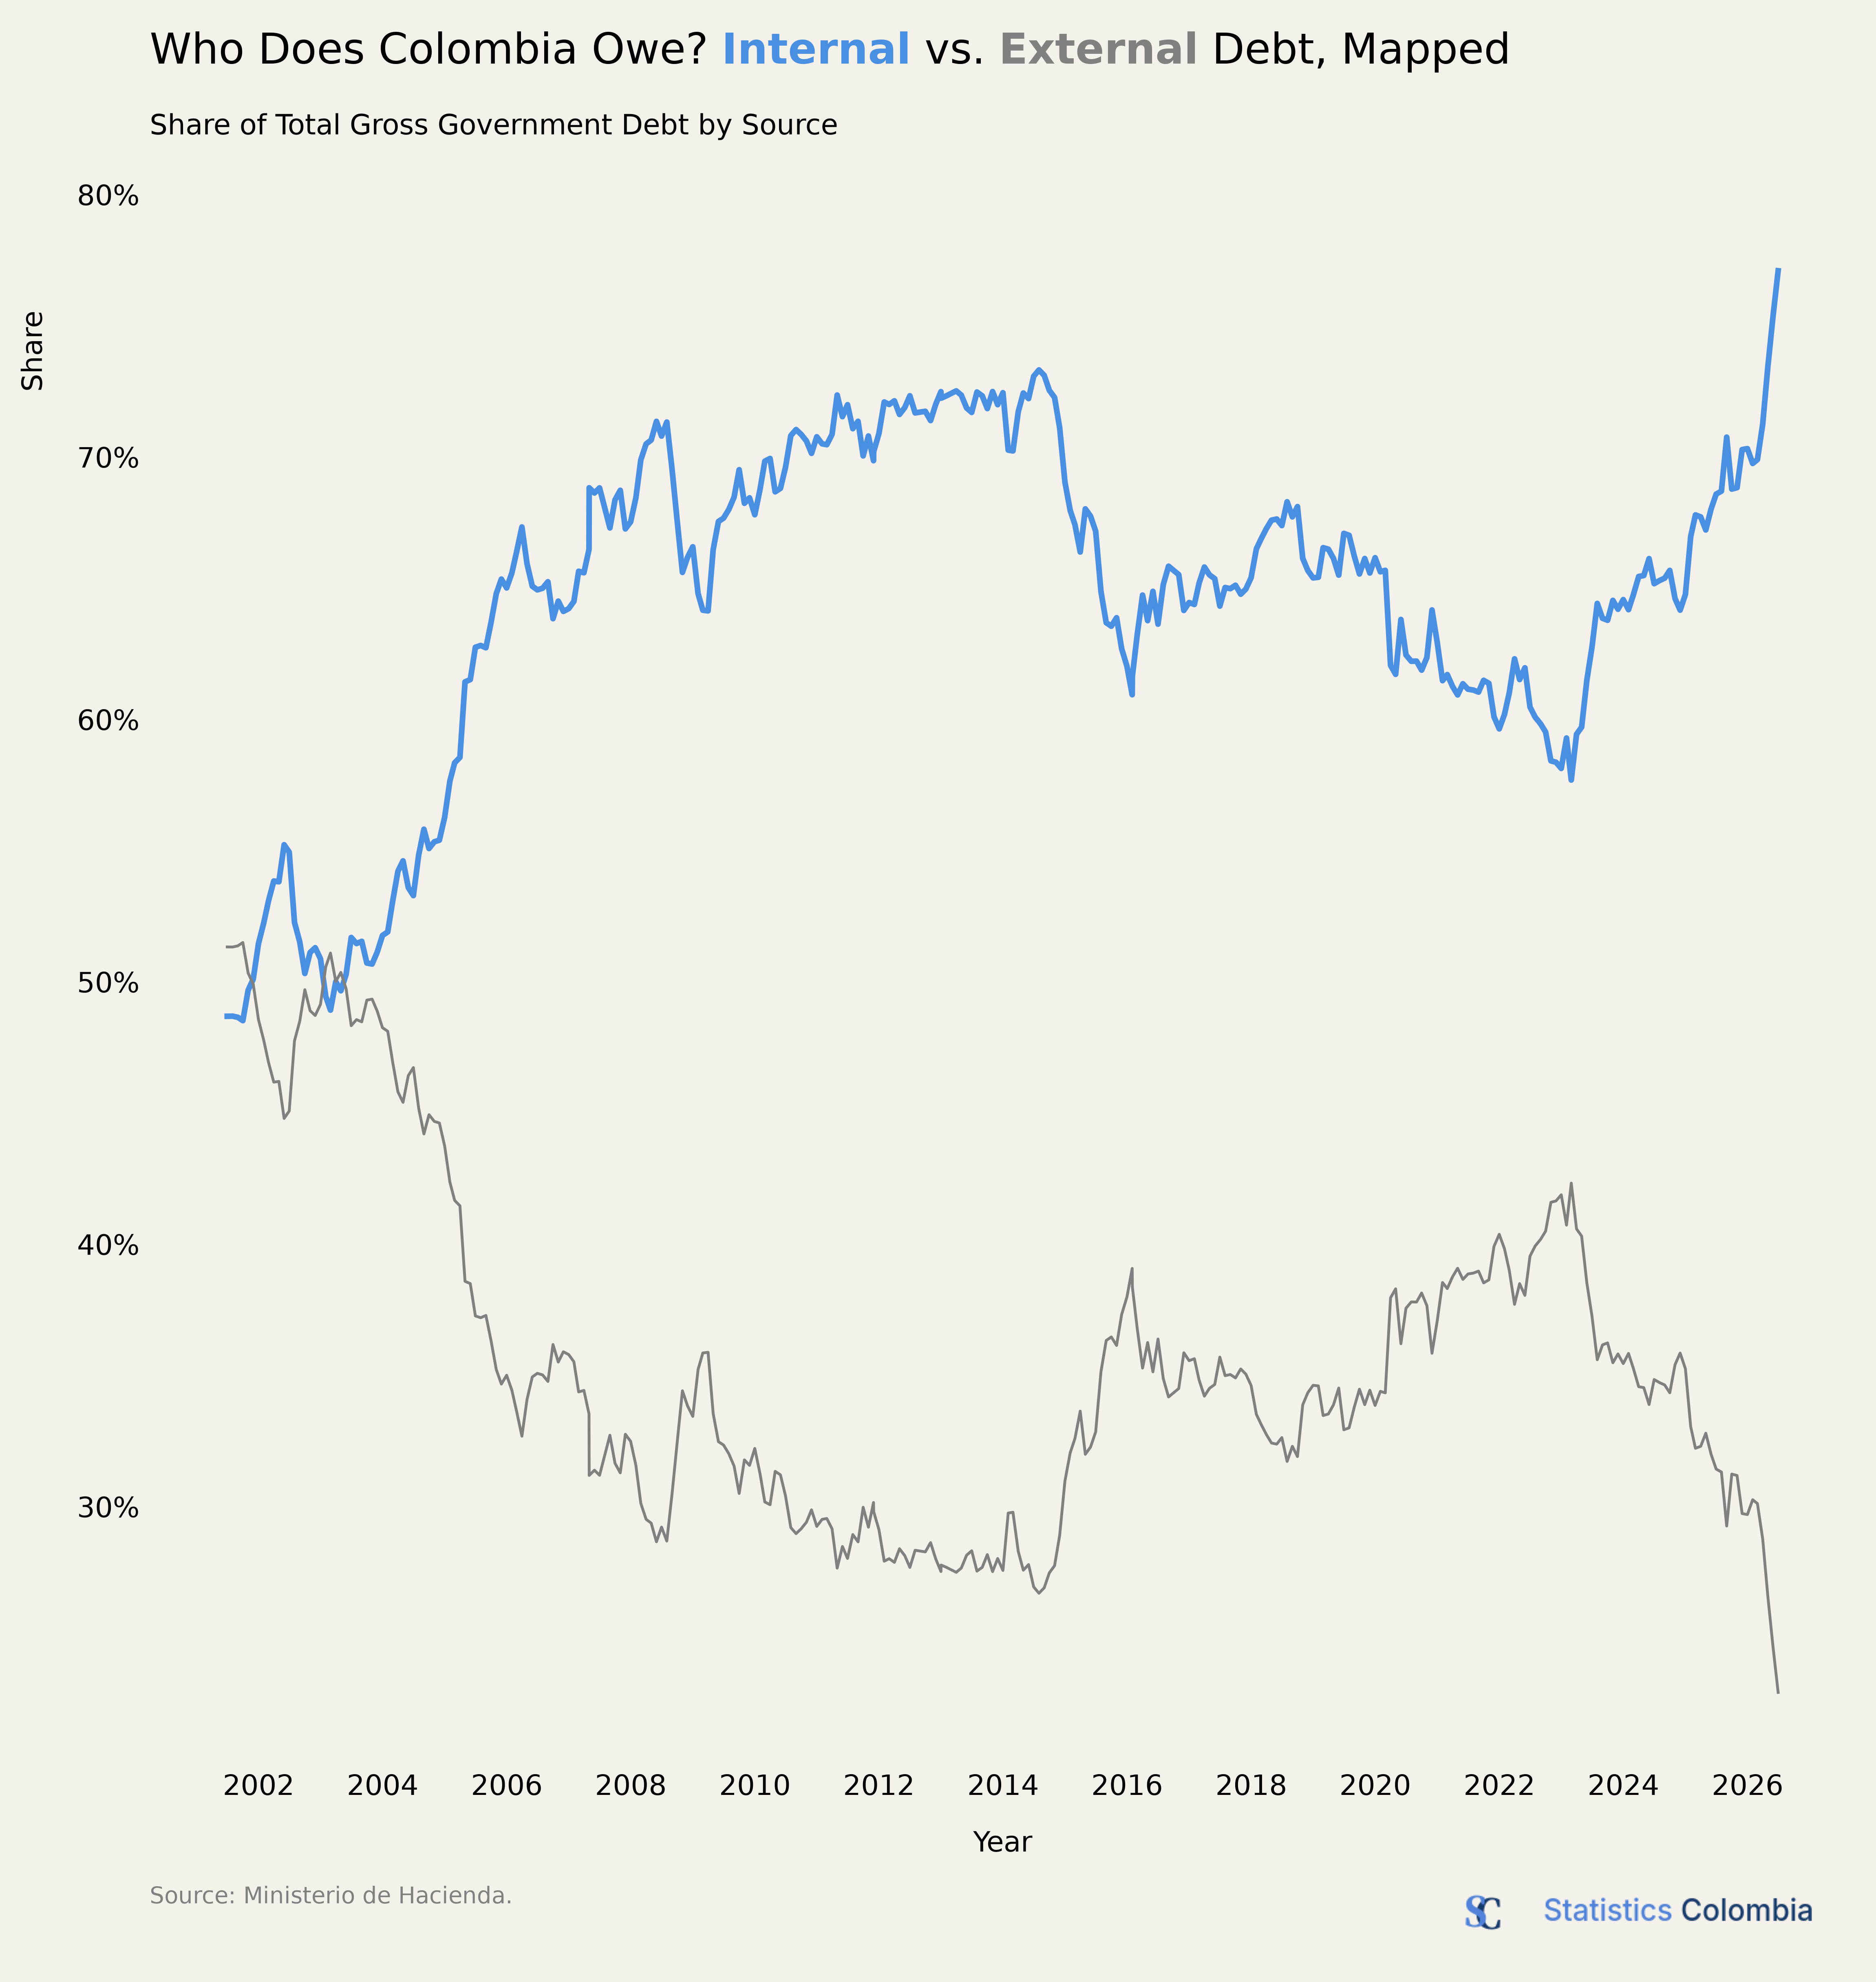

In [96]:
blue = "#4a90e2"
gray = "#808080"
x_axis = pctg_change.index

fig, ax = plt.subplots(figsize=(10.8, 10), dpi=500)
fig.patch.set_facecolor("#F4F1EA")
ax.patch.set_facecolor("#F4F1EA")

plt.plot(x_axis, pctg_change["Internal"], linewidth=2, color=blue)
plt.plot(x_axis, pctg_change["External"], linewidth=1, color=gray)

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))

years = pd.date_range(start="2002-01-01", periods=13, freq="2YS")
plt.xticks(years)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.yticks(range(30, 90, 10))

plt.ylabel("Share", labelpad=10, fontsize=10, y=0.9)
plt.xlabel("Year", labelpad=10, fontsize=10)

for side in ["top", "bottom", "left", "right"]:
    plt.gca().spines[side].set_visible(False)

for axis in ["y", "x"]:
    plt.tick_params(axis=axis, length=0)

fig_text(
    x=0.125, y=0.96,
    s="Who Does Colombia Owe? <Internal> vs. <External> Debt, Mapped",
    highlight_textprops=[
        {"color": blue, "weight": "bold"},
        {"color": gray, "weight": "bold"}
    ],
    fontsize=15
)

fig_text(
    x=0.125, y=0.92,
    s="Share of Total Gross Government Debt by Source",
    fontsize=10
)

fig_text(
    0.125, 0.05, 
    "Source: Ministerio de Hacienda.\n", 
    fontsize=8, color="gray",
)

imagebox = OffsetImage(logo, zoom=0.4)

ab = AnnotationBbox(imagebox, xy=(0.75, 0.035), xycoords="figure fraction",
                    frameon=False, pad=0)

plt.gca().add_artist(ab)

plt.show()